In [15]:
from keras.models import Sequential
from keras.layers import Dense, Input, Conv2D, MaxPool2D, Flatten, Dropout
from keras.utils import plot_model, to_categorical
from keras.datasets import cifar10
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from keras.layers import BatchNormalization as BatchNormization

In [5]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 77s 0us/step


In [8]:
x_train.shape
# Output: (50000, 32, 32, 3)

(50000, 32, 32, 3)

In [9]:

x_test.shape
# Output: (10000, 32, 32, 3)

(10000, 32, 32, 3)

In [11]:

labels=['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

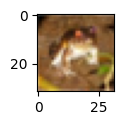

In [12]:
plt.figure(figsize=(1,1))
plt.imshow(x_train[0])

In [16]:
model = Sequential()

model.add(Input(shape=(32,32,3)))
model.add(Conv2D(filters=128, kernel_size=(5,5), strides=(1,1),
                 activation='relu'))
model.add(BatchNormization())
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Conv2D(filters=256, kernel_size=(3,3), strides=(1,1),
                 activation='relu'))
model.add(BatchNormization())
model.add(MaxPool2D(pool_size=(3,3)))
model.add(Conv2D(filters=256, kernel_size=(3,3), strides=(1,1),
                 activation='relu'))
model.add(BatchNormization())
model.add(Conv2D(filters=256, kernel_size=(1,1), strides=(1,1),
                 activation='relu'))
model.add(BatchNormization())
model.add(Conv2D(filters=256, kernel_size=(1,1), strides=(1,1),
                 activation='relu'))
model.add(BatchNormization())
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(1024, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 128)    │         9,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 2, 2, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 2, 2, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 2, 2, 256)      │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 2, 2, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 2, 2, 256)      │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 2, 2, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 1, 1, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,824,266 (6.96 MB)

 Trainable params: 1,821,962 (6.95 MB)

 Non-trainable params: 2,304 (9.00 KB)

In [17]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [19]:
model.fit(x_train , y_train, epochs = 30, validation_data=(x_test, y_test))

Epoch 1/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.4242 - loss: 1.5949 - val_accuracy: 0.4674 - val_loss: 1.4689
Epoch 2/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.5557 - loss: 1.2731 - val_accuracy: 0.4709 - val_loss: 1.5385
Epoch 3/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.6241 - loss: 1.1031 - val_accuracy: 0.5754 - val_loss: 1.2523
Epoch 4/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.6700 - loss: 0.9808 - val_accuracy: 0.6772 - val_loss: 0.9599
Epoch 5/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.7074 - loss: 0.8743 - val_accuracy: 0.6806 - val_loss: 0.9470
Epoch 6/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.7386 - loss: 0.7882 - val_accuracy: 0.6773 - val_loss: 0.9216
Epoch 7/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.7661 - loss: 0.7083 - val_accuracy: 0.7356 - val_loss: 0.8116
Epoch 8/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.7881 - loss: 

Text(0.5, 1.0, 'horse')

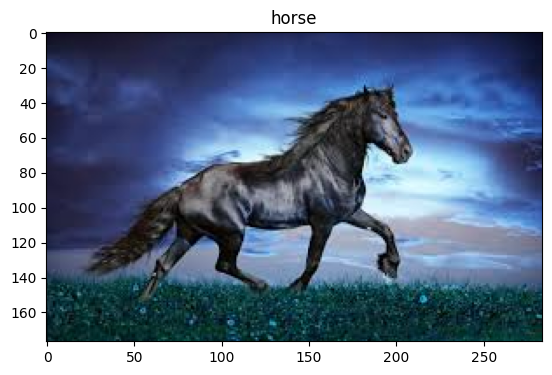

In [25]:
import cv2
img = cv2.imread('Horse.jpg')
plt.imshow(img)
img = cv2.resize(img, (32,32))
img = np.expand_dims(img, axis=0)
result = model.predict(img, verbose = False)
plt.title(labels[result[0].argmax()])